# 💳 Credit Card Fraud Detection using Machine Learning

## 📌 Project Overview

Credit card fraud is one of the major challenges in the financial industry. Fraudulent transactions represent only a very small portion of all transactions, making fraud detection a highly imbalanced classification problem.

The objective of this project is to analyze credit card transaction data, explore transaction patterns, and develop machine learning models capable of identifying fraudulent transactions.

---

## 📂 Project Workflow

1. Import Libraries
2. Upload and Load Dataset
3. Data Exploration
4. Data Cleaning
5. Exploratory Data Analysis (EDA)
6. Data Preprocessing
7. Feature Scaling
8. Model Building
9. Model Evaluation
10. Conclusion

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

## 2. Upload and Load the Dataset

The dataset is uploaded from the local computer and loaded into a pandas DataFrame for further analysis.

In [4]:
from google.colab import files

uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


In [5]:
df = pd.read_csv("creditcard.csv")

## 3. Explore the Dataset

Before building any machine learning model, it is important to understand the dataset by checking:

- Dataset dimensions
- Data types
- Missing values
- Summary statistics

In [6]:
print("Dataset Shape")
print(df.shape)

print("\n")

print("Dataset Information")
df.info()

print("\n")

print("Summary Statistics")
display(df.describe())

Dataset Shape
(284807, 31)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20 

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## 3. Check Missing Values

Missing values can negatively affect data analysis and machine learning models. Before proceeding, we verify whether the dataset contains any missing values.

In [8]:
# Check missing values

missing_values = df.isnull().sum()

display(missing_values)
missing_values[missing_values > 0]

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


,0


### Interpretation

No missing values were found in the dataset. Therefore, no additional data cleaning is required for missing data.

## 4. Check Duplicate Records

Duplicate transactions may introduce bias into the analysis. We check whether duplicate records exist in the dataset.

In [9]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 1081


In [10]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


## 5. Explore the Target Variable

The target variable (`Class`) indicates whether a transaction is fraudulent.

- 0 = Legitimate Transaction
- 1 = Fraudulent Transaction

Understanding the class distribution is important because highly imbalanced datasets require special attention during model development.

In [12]:
df["Class"].value_counts()
(df["Class"].value_counts(normalize=True) * 100).round(3)

,proportion
Class,
0,99.833
1,0.167


## 6. Visualize Class Distribution

We visualize the distribution of fraudulent and legitimate transactions to better understand the imbalance in the dataset.

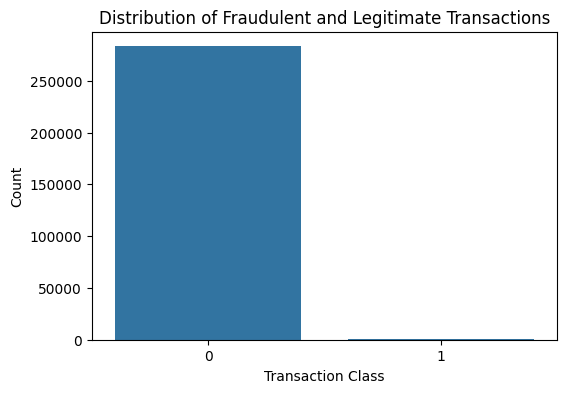

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")

plt.show()

### Interpretation

The dataset is highly imbalanced. Legitimate transactions represent the vast majority of observations, while fraudulent transactions account for only a very small percentage.

This imbalance should be considered when selecting evaluation metrics and machine learning techniques.

## 7. Analyze Transaction Amount

We examine the statistical distribution of transaction amounts to better understand customer spending behavior.

In [14]:
df["Amount"].describe()

,Amount
count,283726.000000
mean,88.472687
std,250.399437
min,0.000000
25%,5.600000
50%,22.000000
75%,77.510000
max,25691.160000


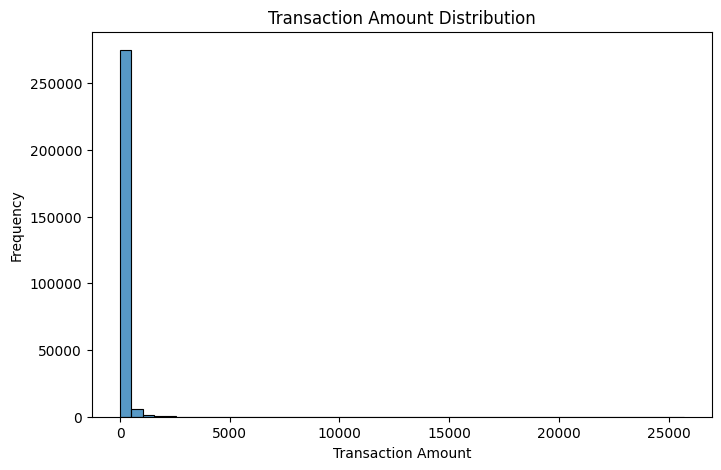

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

## 8. Detecting Outliers in Transaction Amount

A box plot is used to identify potential outliers in transaction amounts.

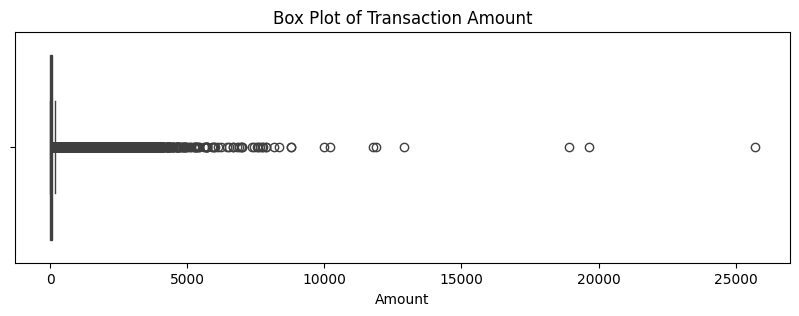

In [21]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df["Amount"])

plt.title("Box Plot of Transaction Amount")

plt.show()

## 9. Transaction Time Analysis

The `Time` feature represents the number of seconds elapsed between each transaction and the first transaction in the dataset.

Analyzing its distribution helps us understand when transactions occurred throughout the recorded period.

In [22]:
# Summary statistics for transaction time

df["Time"].describe()

,Time
count,283726.000000
mean,94811.077600
std,47481.047891
min,0.000000
25%,54204.750000
50%,84692.500000
75%,139298.000000
max,172792.000000


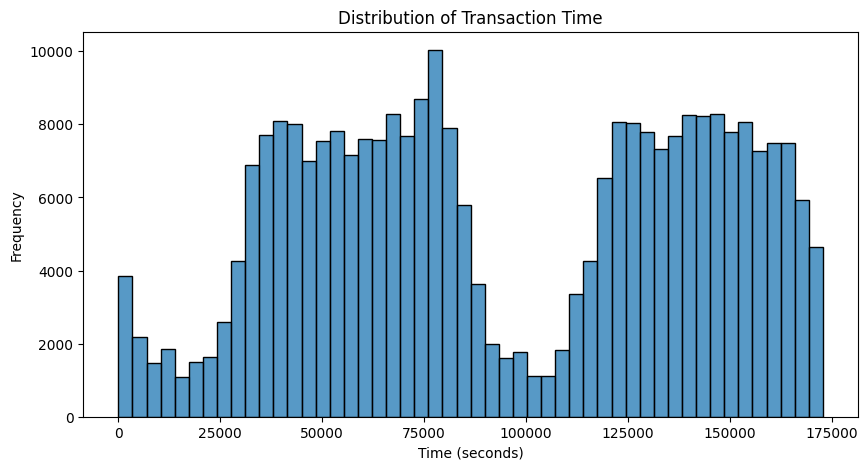

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

## 10. Compare Transaction Amount by Class

Comparing transaction amounts between legitimate and fraudulent transactions may reveal useful patterns for fraud detection.

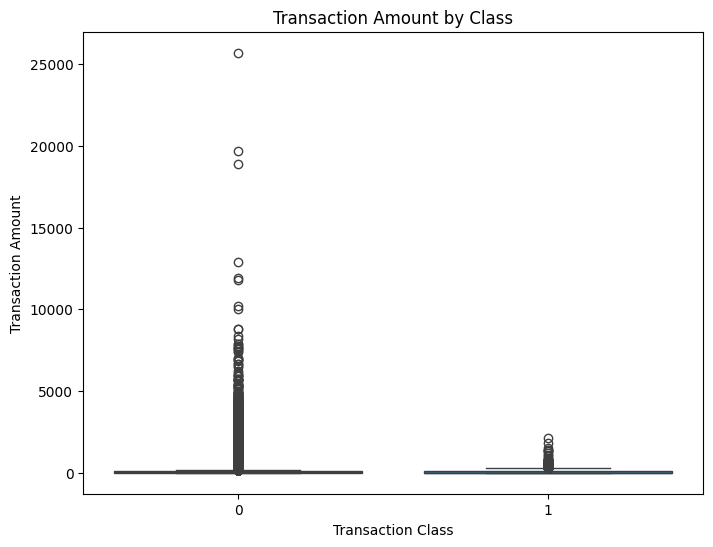

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.show()

## 11. Correlation Analysis

A correlation matrix helps identify relationships between numerical variables and provides insight into which features may be associated with fraudulent transactions.

In [25]:
correlation = df.corr()

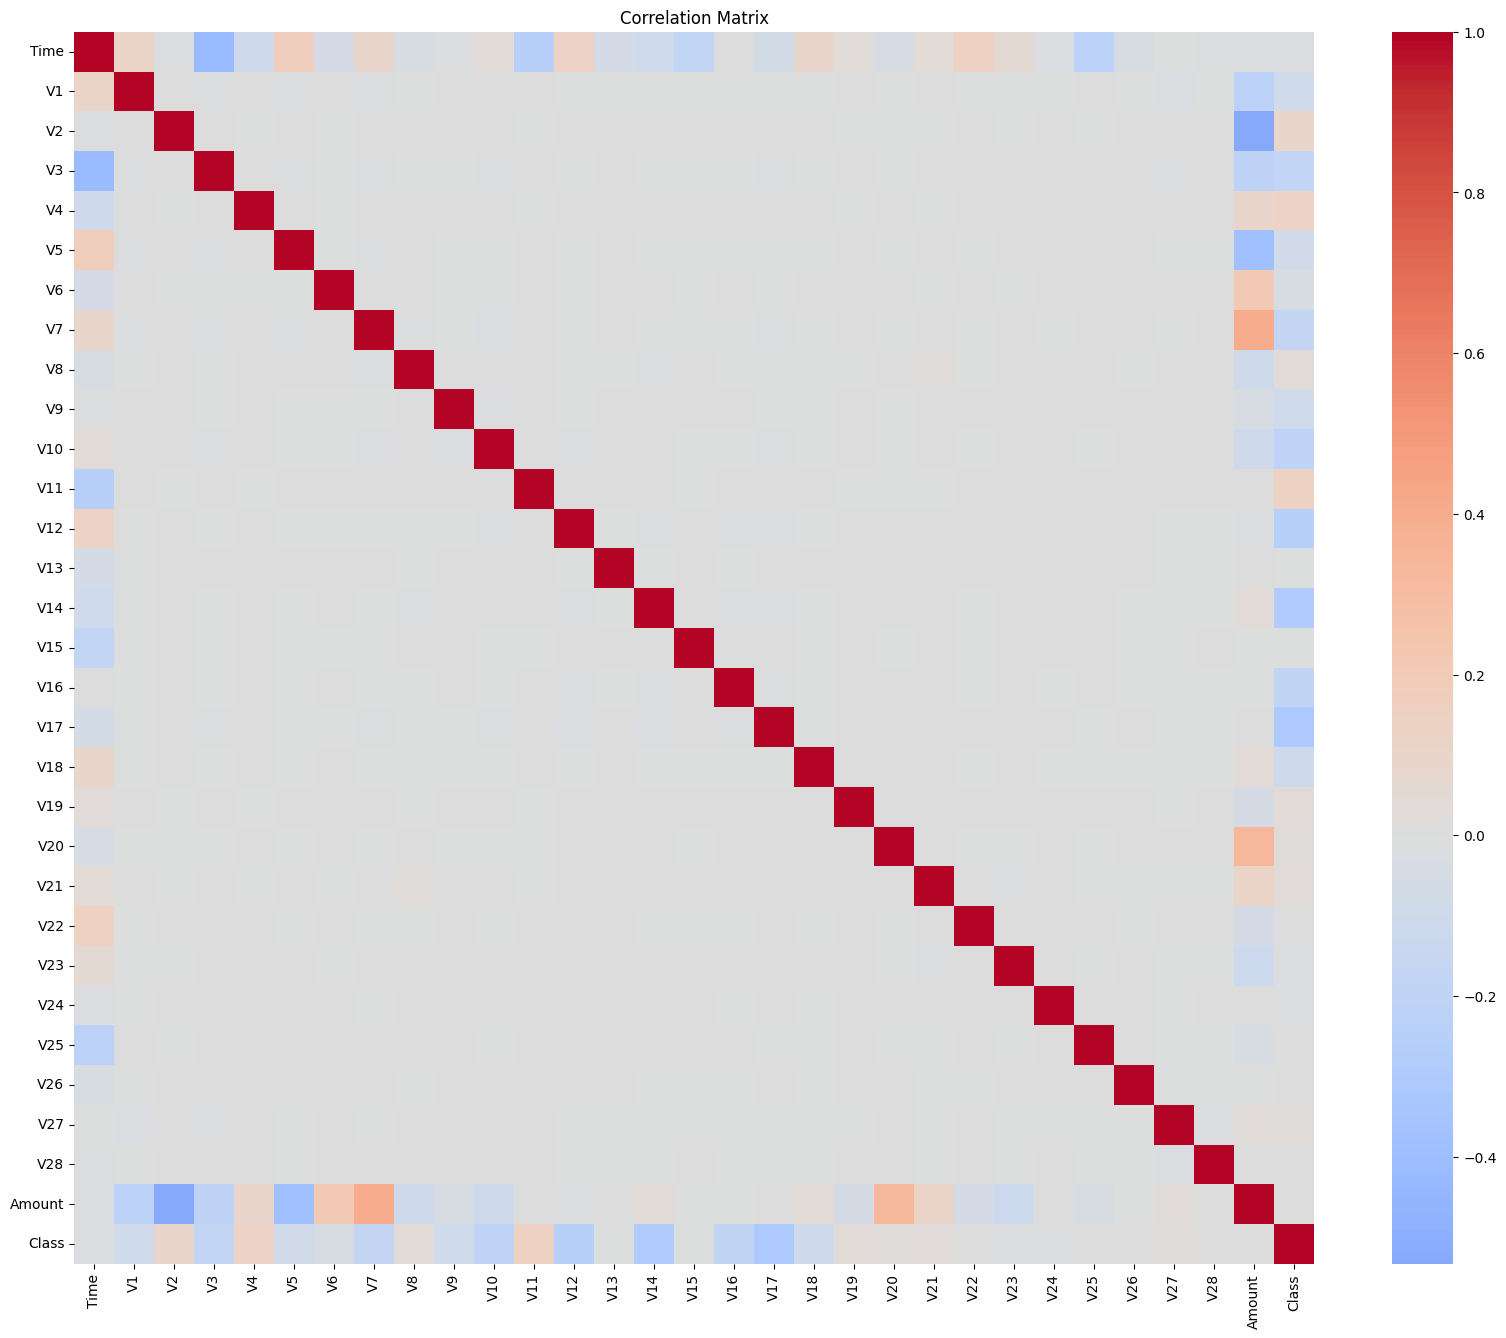

In [26]:
plt.figure(figsize=(20,16))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 12. Features Most Correlated with Fraud

To better understand which variables are associated with fraudulent transactions, we examine the correlation of each feature with the target variable (`Class`).

In [27]:
fraud_corr = df.corr()["Class"].sort_values(ascending=False)

fraud_corr

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


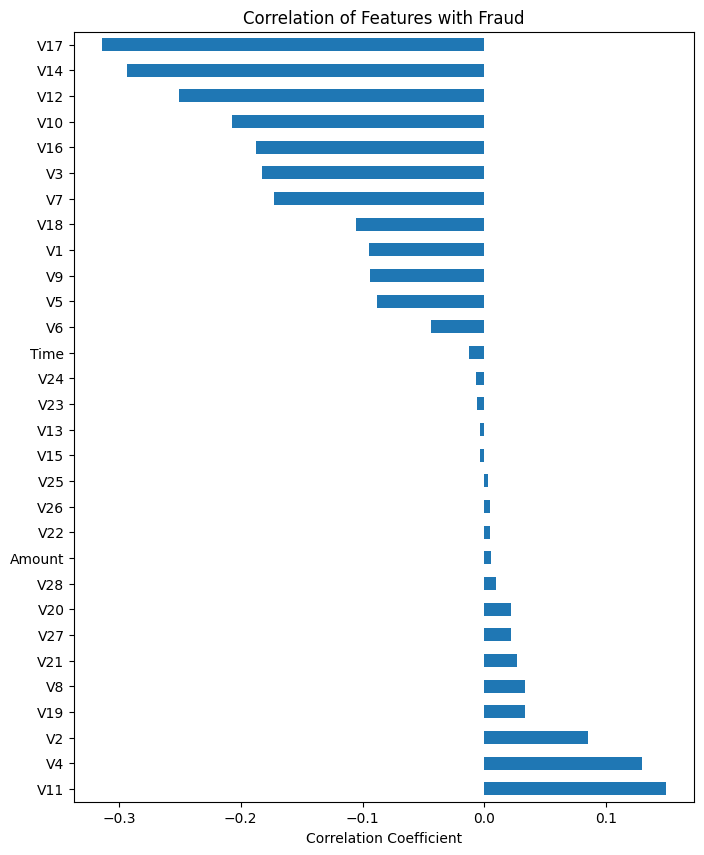

In [28]:
plt.figure(figsize=(8,10))

fraud_corr.drop("Class").plot(kind="barh")

plt.title("Correlation of Features with Fraud")
plt.xlabel("Correlation Coefficient")

plt.show()

## 13. Feature Scaling

Most features in this dataset have already been transformed using Principal Component Analysis (PCA). However, the `Time` and `Amount` features are not scaled.

To ensure consistent feature ranges and improve model performance, we standardize these two features using `StandardScaler`.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


## 14. Define Features and Target

The dataset is divided into:

- **Features (X):** Independent variables used for prediction.
- **Target (y):** The `Class` column indicating whether a transaction is fraudulent.

In [30]:
X = df.drop("Class", axis=1)
y = df["Class"]

## 15. Split the Dataset

The dataset is divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

The `stratify` parameter is used to preserve the original class distribution in both sets.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (226980, 30)
Testing Set: (56746, 30)


## 16. Logistic Regression

Logistic Regression is a widely used classification algorithm that estimates the probability of an observation belonging to a specific class.

It serves as a strong baseline model for binary classification problems such as fraud detection.

In [33]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

## 17. Model Prediction

After training the model, predictions are generated using the testing dataset.

In [34]:
y_pred = lr_model.predict(X_test)

## 18. Model Evaluation

To evaluate the model, we calculate:

- Accuracy
- Precision
- Recall
- F1-score

Since fraud detection is an imbalanced classification problem, Precision, Recall, and F1-score are more informative than Accuracy alone.

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9991
Precision: 0.8485
Recall   : 0.5895
F1-Score : 0.6957


## 19. Classification Report

The classification report provides detailed performance metrics for each class.

In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



## 20. Confusion Matrix

The confusion matrix summarizes the model's predictions by comparing actual and predicted classes.

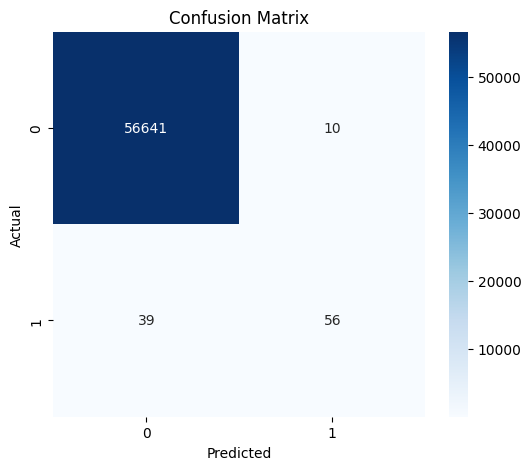

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 21. ROC Curve and AUC Score

The ROC curve shows the trade-off between the True Positive Rate and False Positive Rate.

The AUC score measures how well the model separates fraudulent transactions from legitimate ones.

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities for the positive class
y_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.9584


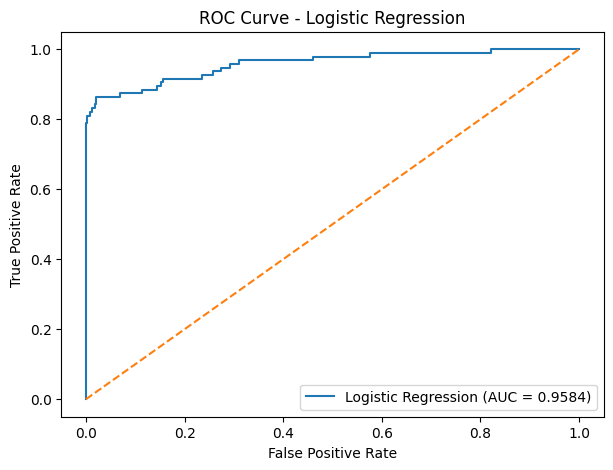

In [39]:
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

### Interpretation

The Logistic Regression model achieved an accuracy of **99.91%**.

Although the model performed well overall, it achieved a **Recall of 58.95%**, meaning that it failed to detect a considerable number of fraudulent transactions.

However, the model obtained a **ROC-AUC score of 95.84%**, indicating an excellent ability to distinguish between legitimate and fraudulent transactions.

Overall, Logistic Regression provides a strong baseline model, but its relatively low recall makes it less suitable as the final model for fraud detection.

## 22. Decision Tree Evaluation

A Decision Tree is a supervised machine learning algorithm that splits the data into branches based on feature values.

It is easy to interpret and can capture non-linear patterns in the data.

In [40]:
from sklearn.tree import DecisionTreeClassifier

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [41]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_auc = roc_auc_score(y_test, dt_prob)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

Accuracy : 0.9990
Precision: 0.7204
Recall   : 0.7053
F1-Score : 0.7128
ROC-AUC  : 0.8524


In [42]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



### Interpretation

The Decision Tree model achieved an accuracy of **99.90%**.

Compared to Logistic Regression, the model achieved a higher **Recall (70.53%)**, meaning it detected more fraudulent transactions.

However, its **Precision (72.04%)** and **ROC-AUC (85.24%)** were lower, indicating a higher number of false positive predictions and weaker overall discrimination between the two classes.

Overall, the Decision Tree model performed reasonably well but was less reliable than the Random Forest model.

## 23. Random Forest Model

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [43]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [44]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

Accuracy : 0.9995
Precision: 0.9718
Recall   : 0.7263
F1-Score : 0.8313
ROC-AUC  : 0.9239


In [45]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



### Interpretation

The Random Forest model achieved an accuracy of **99.95%**.

It obtained a **Precision of 97.18%**, meaning that when the model predicts a transaction as fraudulent, it is correct most of the time.

The model achieved a **Recall of 72.63%**, indicating that it successfully identified approximately 73% of all fraudulent transactions.

Overall, the model achieved an **F1-score of 83.13%**, demonstrating a strong balance between precision and recall. This makes Random Forest a robust model for fraud detection.

## 24. Model Comparison

In this section, we compare the performance of all trained models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [55]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1-Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        auc_score,
        dt_auc,
        rf_auc
    ]
})

comparison.round(4).style.highlight_max(axis=0)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.999100,0.848500,0.589500,0.695700,0.958400
1,Decision Tree,0.999000,0.720400,0.705300,0.712800,0.852400
2,Random Forest,0.999500,0.971800,0.726300,0.831300,0.923900


### Interpretation

Three machine learning models were evaluated for fraud detection.

Although all models achieved very high accuracy, accuracy alone is not an appropriate metric because the dataset is highly imbalanced.

Among the evaluated models:

- Logistic Regression achieved the highest ROC-AUC score, indicating excellent class discrimination.
- Decision Tree improved recall but showed weaker overall performance.
- Random Forest achieved the highest Precision, Recall, and F1-score, providing the best balance between detecting fraudulent transactions and minimizing false positives.

Based on the evaluation metrics, **Random Forest was selected as the best-performing model** for this project.

## 25. Feature Importance

Feature importance helps identify which variables contributed most to the Random Forest model's predictions.

In [53]:
# Create a DataFrame for feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 10 most important features
feature_importance.head(10).style.background_gradient(cmap="Blues")


,Feature,Importance
17,V17,0.156591
14,V14,0.135281
12,V12,0.130206
10,V10,0.087799
16,V16,0.072675
11,V11,0.050980
9,V9,0.033680
18,V18,0.031980
4,V4,0.025802
7,V7,0.024569


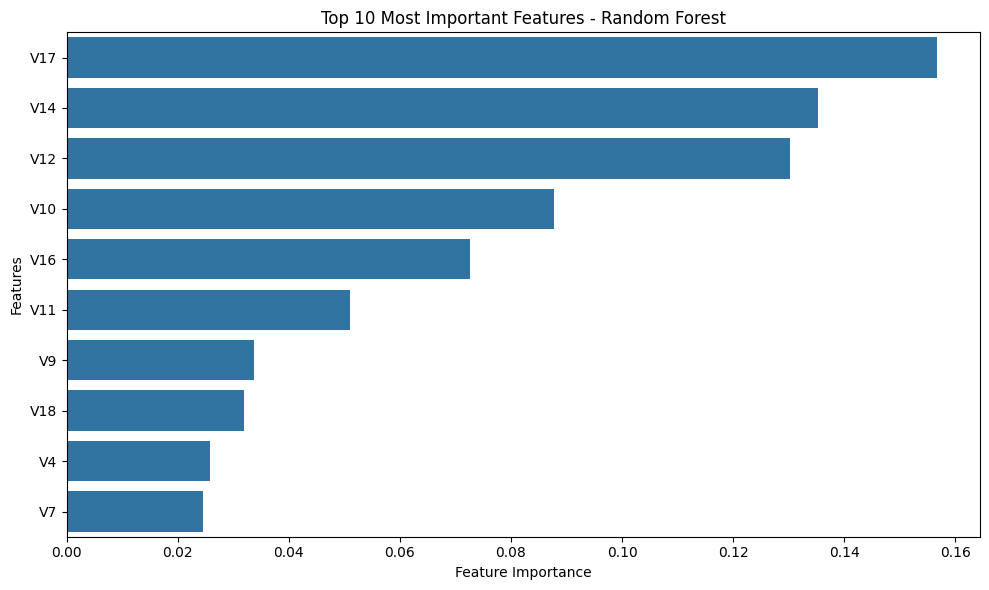

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

### Interpretation

The feature importance analysis identified **V17**, **V14**, and **V12** as the most influential variables in predicting fraudulent transactions.

Since the original variables were transformed using Principal Component Analysis (PCA), their original meanings are not available. Nevertheless, these transformed features contain the strongest predictive information for distinguishing fraudulent and legitimate transactions.

The `Amount` and `Time` features contributed less to the model compared with several PCA-transformed features.

## 26. Final Conclusion

In this project, we built and evaluated three machine learning models for credit card fraud detection:

- Logistic Regression
- Decision Tree
- Random Forest

Although all models achieved very high accuracy, accuracy alone is not reliable for this dataset because the target variable is highly imbalanced.

Random Forest performed the best overall, achieving the highest Precision, Recall, and F1-score. This means it was the most effective model at identifying fraudulent transactions while keeping false positives relatively low.

Therefore, Random Forest was selected as the best-performing model for this fraud detection task.